# Unemployment, Oil Prices & Motor Vehicle Theft (1986–2025)

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.color': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
})


In [2]:
URL_UNRATE = "https://raw.githubusercontent.com/JackSmoot/DS256/refs/heads/main/Final/UNRATE.csv"
URL_OIL    = "https://raw.githubusercontent.com/JackSmoot/DS256/refs/heads/main/Final/MCOILWTICO.csv"
URL_THEFT  = "https://raw.githubusercontent.com/JackSmoot/DS256/refs/heads/main/Final/Motor%20Vehicle%20Theft%20Reported%20by%20Population_04-29-2026%20(1).csv"


## Load & Clean

In [3]:
YEAR_START, YEAR_END = 1986, 2025

# U.S. population by year (millions) — for theft rate per 100k
population = {
    1986:240.13,1987:242.29,1988:244.50,1989:246.82,1990:249.62,
    1991:252.98,1992:256.51,1993:259.92,1994:263.13,1995:266.28,
    1996:269.39,1997:272.65,1998:275.85,1999:279.04,2000:282.16,
    2001:284.97,2002:287.63,2003:290.11,2004:292.81,2005:295.52,
    2006:298.38,2007:301.23,2008:304.09,2009:306.77,2010:309.33,
    2011:311.72,2012:314.01,2013:316.20,2014:318.39,2015:320.74,
    2016:323.07,2017:325.15,2018:327.21,2019:328.24,2020:331.50,
    2021:332.03,2022:333.29,2023:334.91,2024:336.99,2025:339.00,
}

def load_fred(url, col):
    df = pd.read_csv(url, parse_dates=['observation_date'])
    df = df.rename(columns={'observation_date': 'date', col: 'value'})
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    df = df.dropna().set_index('date')['value'].resample('YE').mean()
    df.index = df.index.year
    return df[(df.index >= YEAR_START) & (df.index <= YEAR_END)]

def load_theft(url):
    raw = pd.read_csv(url)
    row = raw[raw['Series'].str.contains('Offenses')].set_index('Series').T.reset_index()
    row.columns = ['month_str', 'value']
    row['date'] = pd.to_datetime(row['month_str'], format='%m-%Y')
    row['value'] = pd.to_numeric(row['value'], errors='coerce')
    s = row.dropna().set_index('date')['value'].resample('YE').sum()
    s.index = s.index.year
    s = s[(s.index >= YEAR_START) & (s.index <= YEAR_END)]
    pop = s.index.map(lambda y: population[y] * 1_000_000)
    return (s / pop * 100_000).round(2)

unrate     = load_fred(URL_UNRATE, 'UNRATE')
oil        = load_fred(URL_OIL,    'MCOILWTICO')
theft_rate = load_theft(URL_THEFT)

df = pd.DataFrame({'unrate': unrate, 'oil': oil, 'theft_rate': theft_rate}).dropna()
print(f"Dataset: {df.index.min()}–{df.index.max()}, {len(df)} years")
df.describe().round(2)


Dataset: 1986–2025, 40 years


,unrate,oil,theft_rate
count,40.00,40.00,40.00
mean,5.70,48.09,373.72
std,1.57,28.72,143.91
min,3.62,14.45,179.28
25%,4.58,20.60,233.89
50%,5.45,42.29,390.00
75%,6.34,69.07,480.77
max,9.61,99.57,639.98


## Chart 1 — Individual Trends

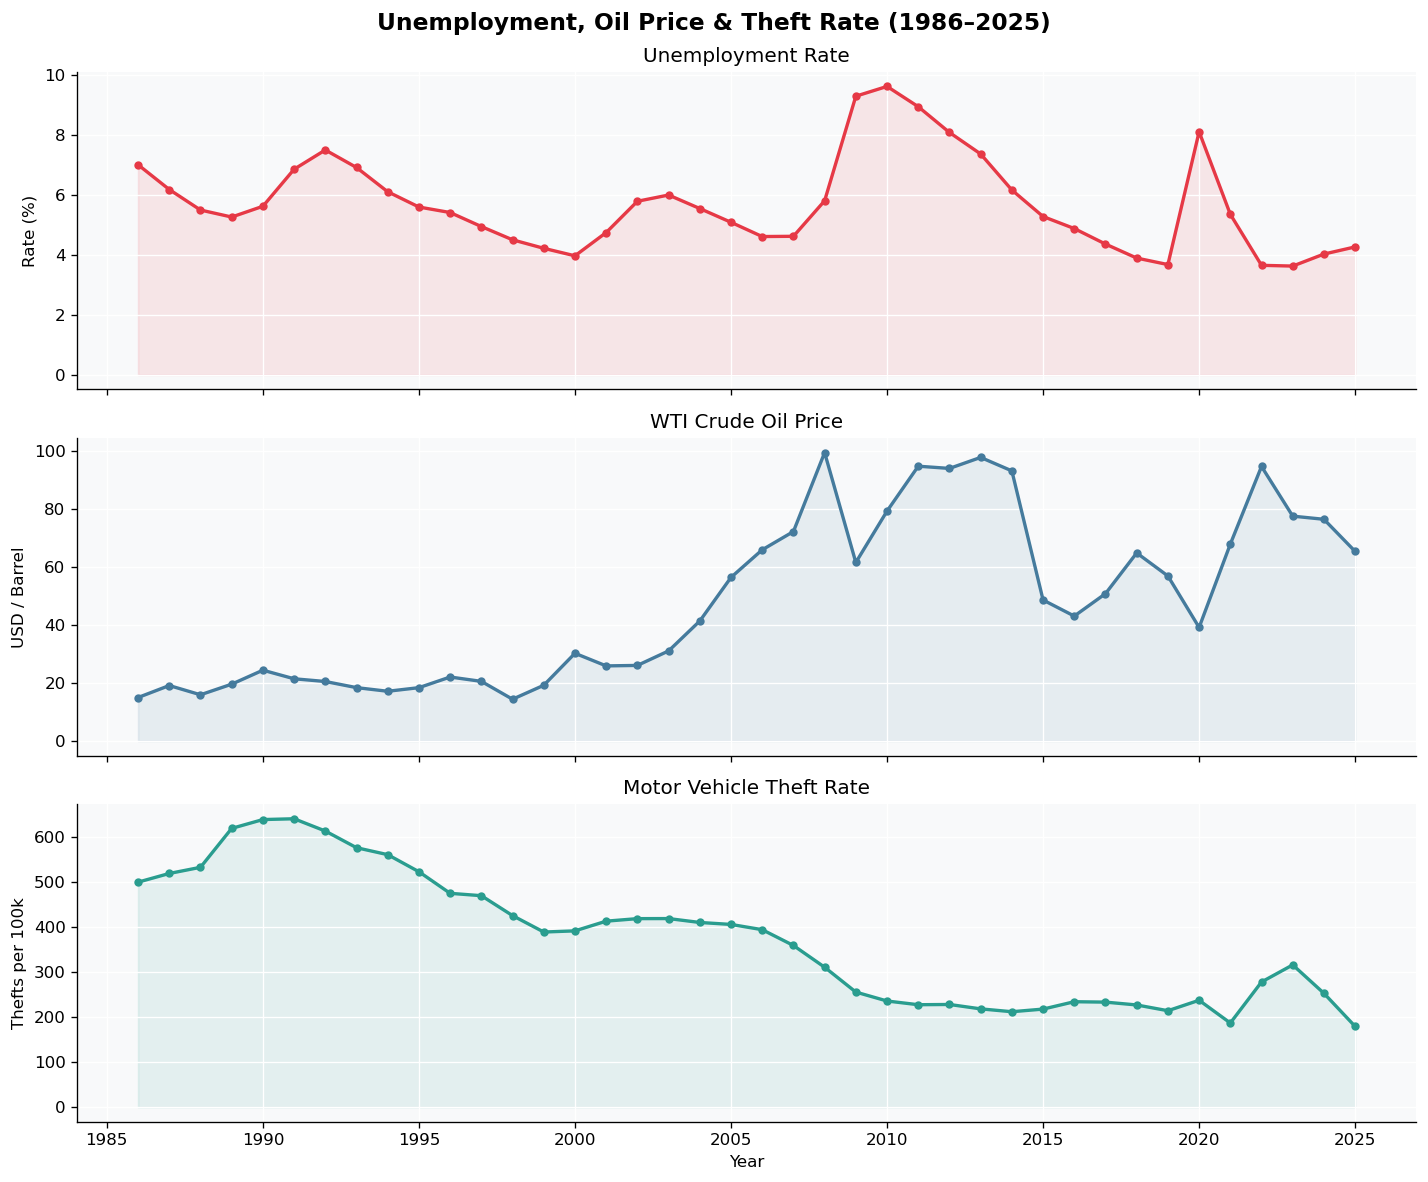

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.suptitle('Unemployment, Oil Price & Theft Rate (1986–2025)', fontsize=14, fontweight='bold')

axes[0].plot(df.index, df['unrate'], color='#e63946', lw=2, marker='o', ms=4)
axes[0].fill_between(df.index, df['unrate'], alpha=0.1, color='#e63946')
axes[0].set_ylabel('Rate (%)')
axes[0].set_title('Unemployment Rate')

axes[1].plot(df.index, df['oil'], color='#457b9d', lw=2, marker='o', ms=4)
axes[1].fill_between(df.index, df['oil'], alpha=0.1, color='#457b9d')
axes[1].set_ylabel('USD / Barrel')
axes[1].set_title('WTI Crude Oil Price')

axes[2].plot(df.index, df['theft_rate'], color='#2a9d8f', lw=2, marker='o', ms=4)
axes[2].fill_between(df.index, df['theft_rate'], alpha=0.1, color='#2a9d8f')
axes[2].set_ylabel('Thefts per 100k')
axes[2].set_title('Motor Vehicle Theft Rate')
axes[2].set_xlabel('Year')

plt.tight_layout()
plt.show()


## Chart 2 — Normalized Overlay
All three variables scaled to 0–1 so they can be compared on one axis.

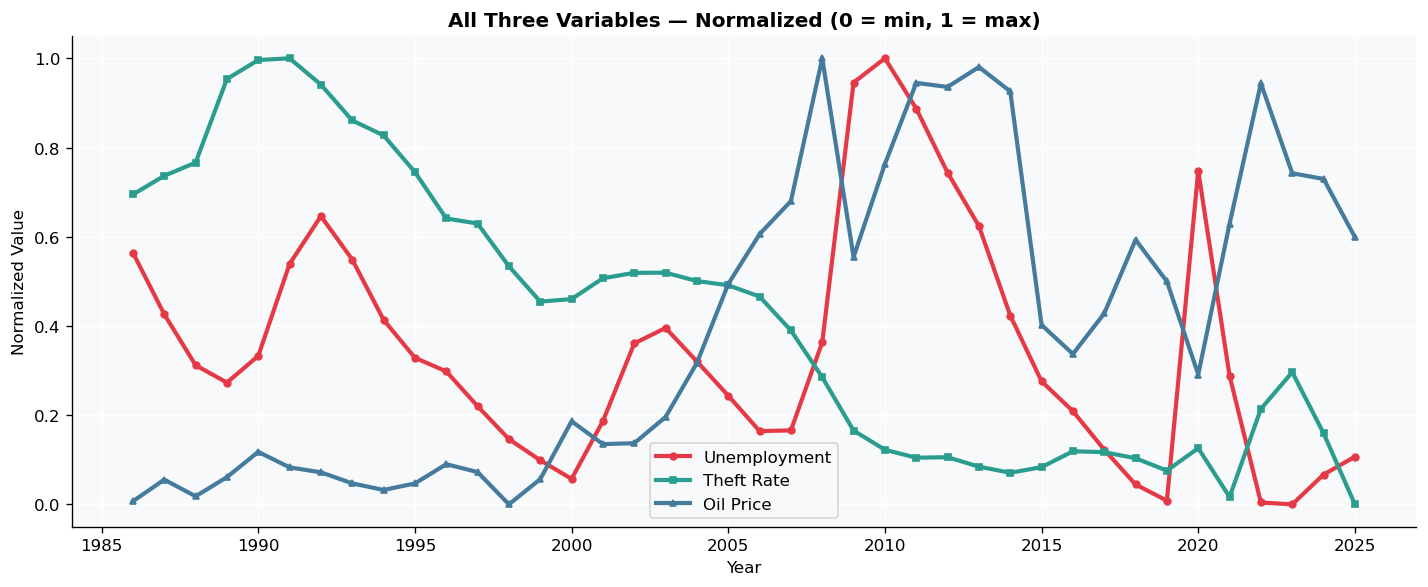

In [5]:
def norm(s): return (s - s.min()) / (s.max() - s.min())

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df.index, norm(df['unrate']),     color='#e63946', lw=2.5, marker='o', ms=4, label='Unemployment')
ax.plot(df.index, norm(df['theft_rate']), color='#2a9d8f', lw=2.5, marker='s', ms=4, label='Theft Rate')
ax.plot(df.index, norm(df['oil']),        color='#457b9d', lw=2.5, marker='^', ms=4, label='Oil Price')

ax.set_title('All Three Variables — Normalized (0 = min, 1 = max)', fontweight='bold')
ax.set_ylabel('Normalized Value')
ax.set_xlabel('Year')
ax.legend()
plt.tight_layout()
plt.show()


## Chart 3 — Oil Price vs. Theft Rate

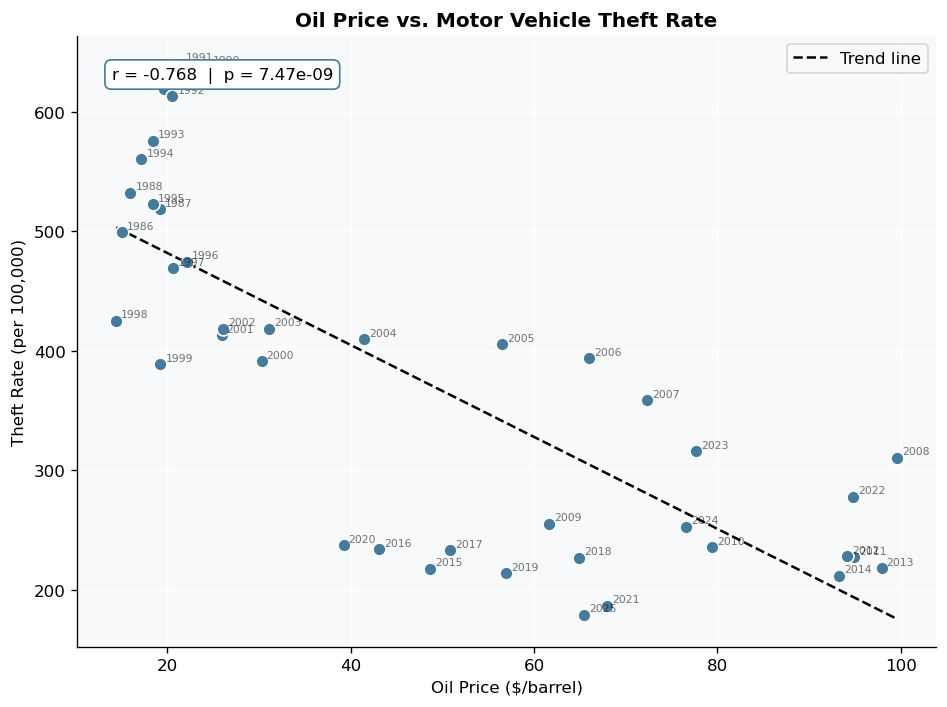

In [6]:
x, y = df['oil'], df['theft_rate']
slope, intercept, r, p, _ = stats.linregress(x, y)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x, y, color='#457b9d', s=60, zorder=3, edgecolors='white')

for yr in df.index:
    ax.annotate(str(yr), (df.loc[yr,'oil'], df.loc[yr,'theft_rate']),
                fontsize=6.5, alpha=0.55, xytext=(3, 2), textcoords='offset points')

xline = np.linspace(x.min(), x.max(), 200)
ax.plot(xline, slope*xline + intercept, color='black', lw=1.5, ls='--', label='Trend line')

ax.set_xlabel('Oil Price ($/barrel)')
ax.set_ylabel('Theft Rate (per 100,000)')
ax.set_title('Oil Price vs. Motor Vehicle Theft Rate', fontweight='bold')
ax.legend()
ax.text(0.04, 0.95, f'r = {r:.3f}  |  p = {p:.3g}',
        transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#457b9d'))
plt.tight_layout()
plt.show()


## Chart 4 — Rolling 10-Year Correlation
Shows whether the relationship between unemployment and theft has strengthened or weakened over time.

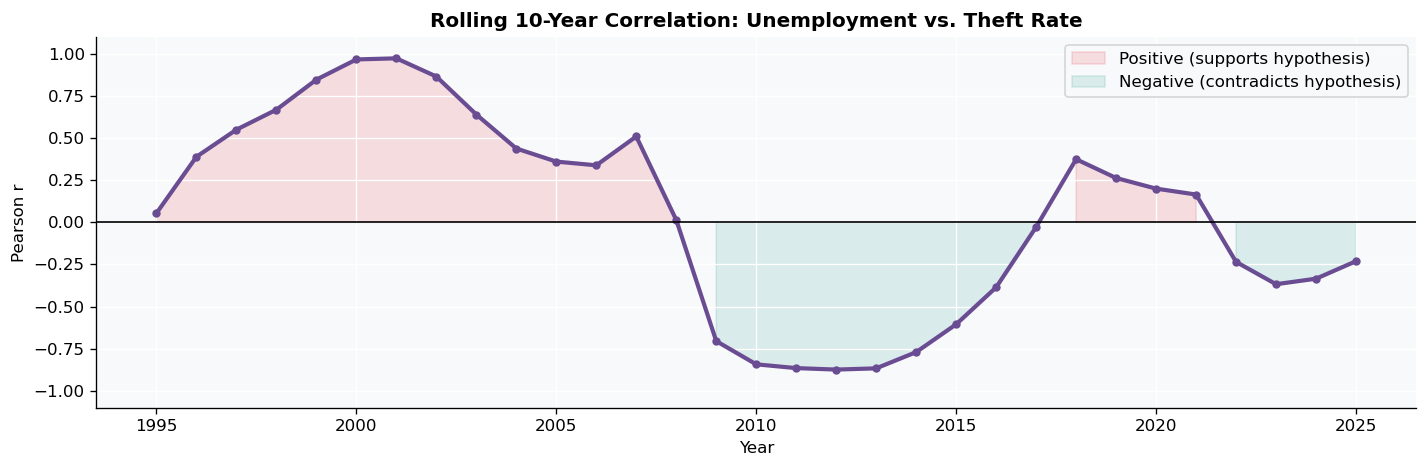

In [7]:
roll_r = df['unrate'].rolling(10).corr(df['theft_rate'])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.index, roll_r, color='#6a4c93', lw=2.5, marker='o', ms=4)
ax.fill_between(df.index, roll_r, 0,
                where=roll_r >= 0, alpha=0.15, color='#e63946', label='Positive (supports hypothesis)')
ax.fill_between(df.index, roll_r, 0,
                where=roll_r < 0,  alpha=0.15, color='#2a9d8f', label='Negative (contradicts hypothesis)')
ax.axhline(0, color='black', lw=1)
ax.set_title('Rolling 10-Year Correlation: Unemployment vs. Theft Rate', fontweight='bold')
ax.set_ylabel('Pearson r')
ax.set_xlabel('Year')
ax.set_ylim(-1.1, 1.1)
ax.legend()
plt.tight_layout()
plt.show()


## Chart 5 — Unemployment vs. Theft Rate
Our hypothesis predicts a positive correlation — the data shows otherwise.

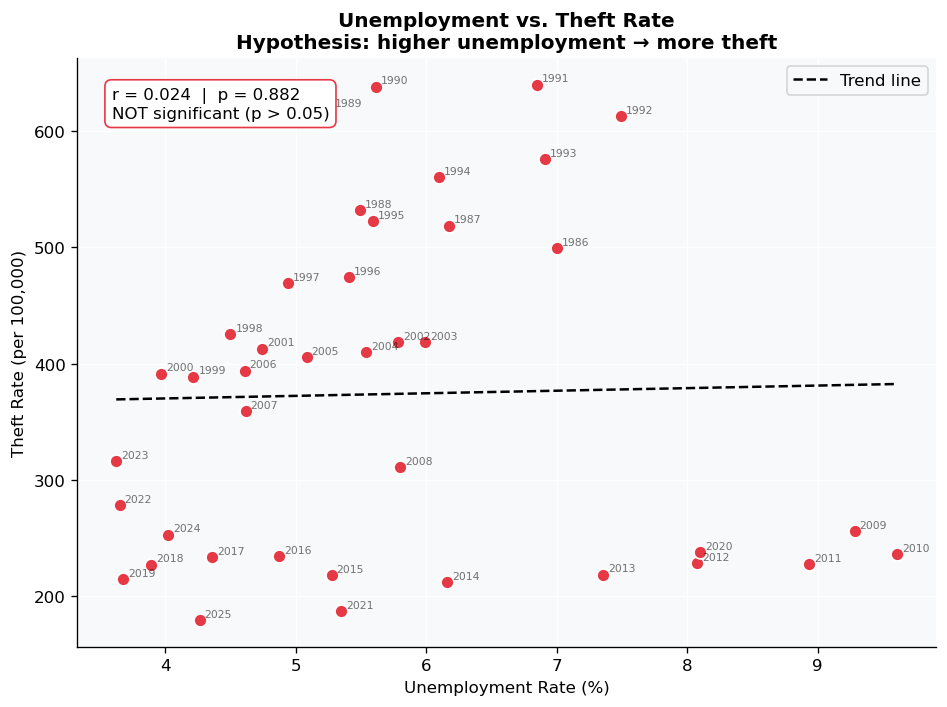

In [8]:
x, y = df['unrate'], df['theft_rate']
slope, intercept, r, p, _ = stats.linregress(x, y)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x, y, color='#e63946', s=60, zorder=3, edgecolors='white')

for yr in df.index:
    ax.annotate(str(yr), (df.loc[yr,'unrate'], df.loc[yr,'theft_rate']),
                fontsize=6.5, alpha=0.55, xytext=(3, 2), textcoords='offset points')

xline = np.linspace(x.min(), x.max(), 200)
ax.plot(xline, slope*xline + intercept, color='black', lw=1.5, ls='--', label='Trend line')

ax.set_xlabel('Unemployment Rate (%)')
ax.set_ylabel('Theft Rate (per 100,000)')
ax.set_title('Unemployment vs. Theft Rate\nHypothesis: higher unemployment → more theft', fontweight='bold')
ax.legend()
ax.text(0.04, 0.95,
        f'r = {r:.3f}  |  p = {p:.3g}\n{"NOT significant (p > 0.05)" if p >= 0.05 else "Significant (p < 0.05)"}',
        transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#e63946'))
plt.tight_layout()
plt.show()


## Chart 6 — Which Relationship Is Actually Significant?
All three pairwise correlations tested. Bar length = strength, color = significance.

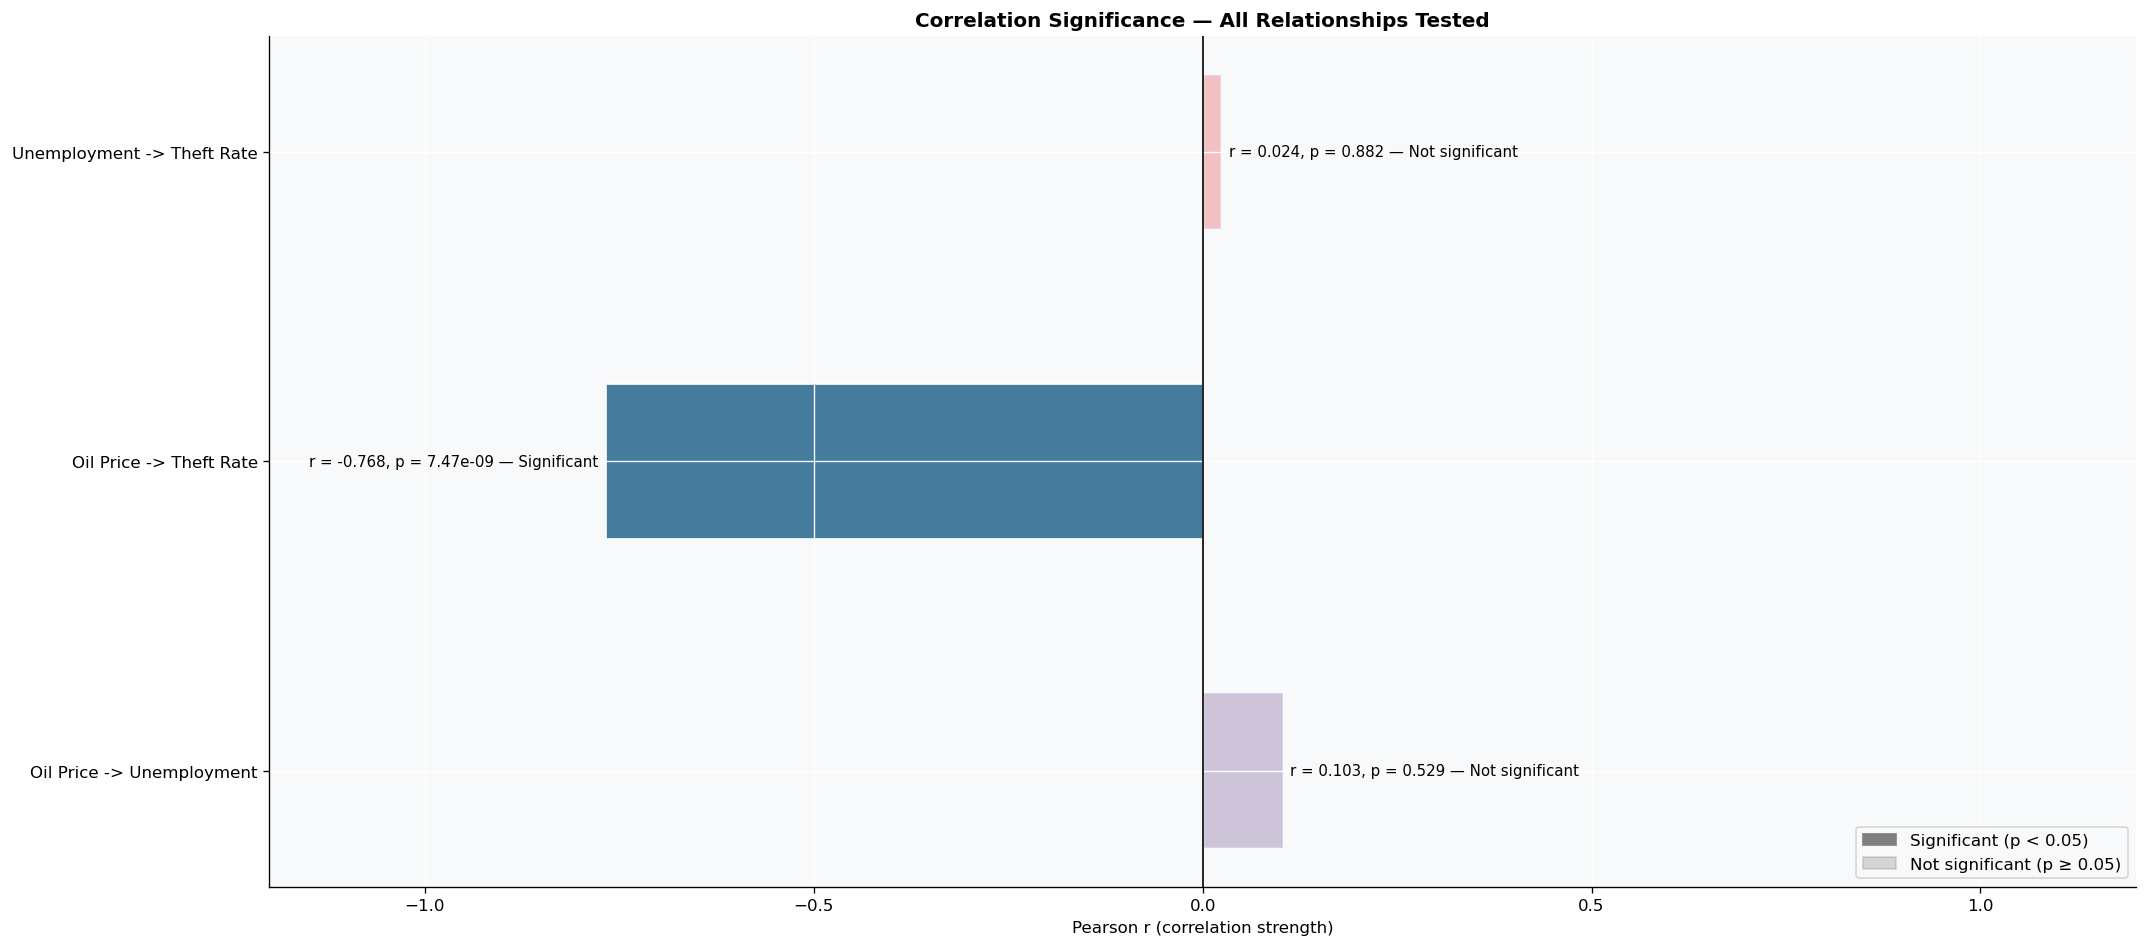

In [12]:
pairs = [
    ('Unemployment -> Theft Rate', 'unrate',     'theft_rate', '#e63946'),
    ('Oil Price -> Theft Rate',    'oil',         'theft_rate', '#457b9d'),
    ('Oil Price -> Unemployment',  'oil',         'unrate',     '#6a4c93'),
]

results = []
for label, col_x, col_y, color in pairs:
    r, p = stats.pearsonr(df[col_x], df[col_y])
    results.append({'label': label, 'r': r, 'p': p, 'color': color,
                    'significant': p < 0.05})

fig, ax = plt.subplots(figsize=(18, 8))
for i, res in enumerate(results):
    alpha = 1.0 if res['significant'] else 0.3
    ax.barh(i, res['r'], color=res['color'], alpha=alpha, edgecolor='white', height=0.5)
    sig_label = f"r = {res['r']:.3f}, p = {res['p']:.3g} — {'Significant' if res['significant'] else 'Not significant'}"
    x_pos = res['r'] + 0.01 if res['r'] >= 0 else res['r'] - 0.01
    ha = 'left' if res['r'] >= 0 else 'right'
    ax.text(x_pos, i, sig_label, va='center', fontsize=9, ha=ha)

ax.set_yticks(range(len(results)))
ax.set_yticklabels([r['label'] for r in results], fontsize=10)
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('Pearson r (correlation strength)')
ax.set_title('Correlation Significance — All Relationships Tested', fontweight='bold')
ax.set_xlim(-1.2, 1.2)
ax.invert_yaxis()

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='grey', alpha=1.0, label='Significant (p < 0.05)'),
                   Patch(color='grey', alpha=0.3, label='Not significant (p ≥ 0.05)')],
          loc='lower right')
plt.tight_layout()
plt.show()


/var/folders/mt/w2zqkpqd1wj65bslf60hdsf40000gn/T/ipykernel_78564/68861722.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([lo, hi],


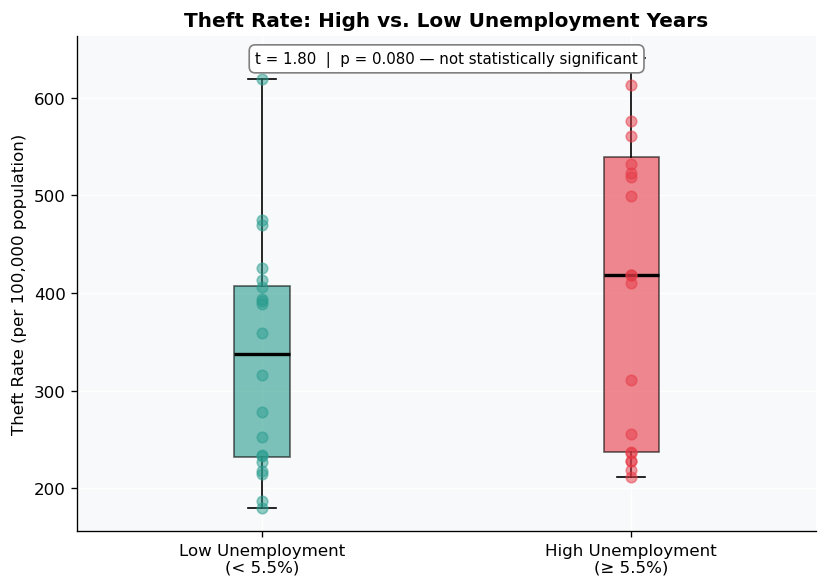

In [13]:
median_u = df['unrate'].median()
hi = df[df['unrate'] >= median_u]['theft_rate']
lo = df[df['unrate'] <  median_u]['theft_rate']

t_stat, p_val = stats.ttest_ind(hi, lo)

fig, ax = plt.subplots(figsize=(7, 5))
bp = ax.boxplot([lo, hi],
                labels=[f'Low Unemployment\n(< {median_u:.1f}%)', f'High Unemployment\n(≥ {median_u:.1f}%)'],
                patch_artist=True,
                medianprops=dict(color='black', lw=2))

bp['boxes'][0].set_facecolor('#2a9d8f')
bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('#e63946')
bp['boxes'][1].set_alpha(0.6)

ax.scatter([1]*len(lo), lo, color='#2a9d8f', alpha=0.5, zorder=3, s=40)
ax.scatter([2]*len(hi), hi, color='#e63946', alpha=0.5, zorder=3, s=40)

ax.set_ylabel('Theft Rate (per 100,000 population)')
ax.set_title('Theft Rate: High vs. Low Unemployment Years', fontweight='bold')

sig = 'not statistically significant' if p_val >= 0.05 else 'statistically significant'
ax.text(0.5, 0.97,
        f't = {t_stat:.2f}  |  p = {p_val:.3f} — {sig}',
        transform=ax.transAxes, ha='center', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='grey'))

plt.tight_layout()
plt.show()